# Lab 2: Signal Analysis, Sampling, Aliasing, and Filtering
Marc Pham

In [10]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7377)

## 3. Task 1: Statistical Properties of Signals

In [25]:
A = 0.5
f0 = 10
fs = 32 * f0
Tobs = 4
N = int(fs*Tobs)
n = np.arange(N)
t = n / fs

x = A * np.cos(2 * np.pi * f0 * t)

### 3.1: Mean, variance, and power

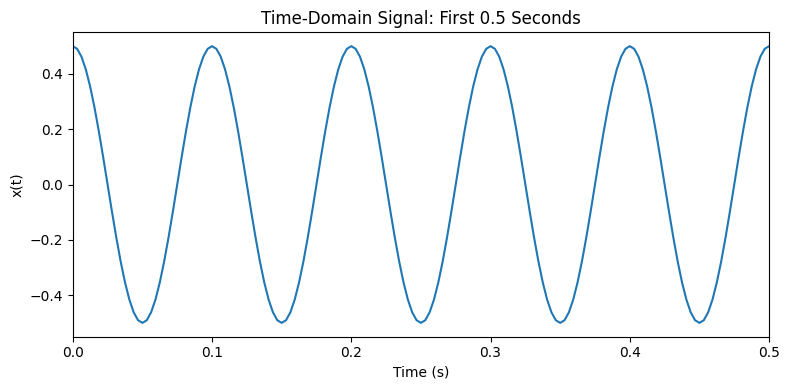

In [3]:
# Change this value to graph a different amount of time
plot_seconds = 0.5

# Select the portion of x(t) to plot
mask = t <= plot_seconds

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(t[mask], x[mask])

ax.set_xlim(0, plot_seconds)
ax.set_xlabel("Time (s)")
ax.set_ylabel("x(t)")
ax.set_title(f"Time-Domain Signal: First {plot_seconds} Seconds")

plt.tight_layout()
plt.show()


The real record $x[n] = A\cos(2\pi f_0 t)$ is a sinusoid with 5 complete cycles over the first 0.5 seconds. Each record starts and ends at equivalent points in the sinusoid, the positive and negative portions cancel exactly for the mean.

The number of samples $N=f_sT=$ 32 samples * 10 Hz * 0.5 seconds = 160 samples for the full 4 second record x[n].

Thus, over the first 0.5 seconds, the finite-record mean $\hat{\mu}_x=\frac1{N}\sum\limits_{n=0}^{N-1}A\cos(2\pi f_0 t)=0$ V.

The finite variance and finite power are $\sigma_x^2=P_x=\frac{A^2}2 = \frac{0.5^2}{2}=0.125 \text{ V}^2$.

The deterministic calculations are run below. Rounding was added to the 12th decimal places to account for Python-based round-off error.

In [4]:
# Finite-record statistics for first 0.5 seconds
x_05 = x[t < 0.5]

mean_x = np.mean(x_05)
variance_x = np.mean((x_05 - mean_x)**2)
power_x = np.mean(x_05**2)

print("N =", len(x_05))
print("Finite-record mean =", round(mean_x, 12), "V")
print("Finite-record variance =", round(variance_x, 12), "V²")
print("Finite-record power =", round(power_x, 12), "V²")


N = 160
Finite-record mean = 0.0 V
Finite-record variance = 0.125 V²
Finite-record power = 0.125 V²


The number of samples $N=f_sT=$ 32 samples * 10 Hz * 4.0 seconds = 1280 samples for the full 4 second record x[n].

The full record x[n] goes for a full 4 seconds and is a sinusoid with 40 complete cycles. Rerunning the deterministic calculation below does not change the mean, variance, and power results because both the 0.5 second and 4 second records contain an integer number of complete cycles of the 10 Hz sinusoid. Thus, both records are zero-mean sinusoids with an integer number of complete cycles.

The theoretical mean $\hat{\mu}_x=\frac1{N}\sum\limits_{n=0}^{N-1}A\cos(2\pi f_0 t)=0$ V.

The theoretical variance and theoretical power are $\sigma_x^2=P_x=\frac{A^2}2 = \frac{0.5^2}{2}=0.125 \text{ V}^2$.

In [5]:
# Theoretical statistics
mean_x2 = np.mean(x)
variance_x2 = np.mean((x - mean_x2)**2)
power_x2 = np.mean(x**2)

print("N =", len(x))
print("Finite-record mean =", round(mean_x2, 12), "V")
print("Finite-record variance =", round(variance_x2, 12), "V²")
print("Finite-record power =", round(power_x2, 12), "V²")


N = 1280
Finite-record mean = -0.0 V
Finite-record variance = 0.125 V²
Finite-record power = 0.125 V²


## 3.2: FFT

In [26]:
X = np.fft.rfft(x)
A = np.abs(X) / N

# Double all positive-frequency bins except DC and Nyquist
if N % 2 == 0: A[1:-1] *= 2 # even N, Nyquist bin exists
else: A[1:] *= 2            # odd N, no Nyquist bin

f = np.fft.rfftfreq(N, d=1/fs)

The frequency-bin spacing $\Delta f=\frac{f_s}{N}=$ 320 samples per second / 1280 samples = 0.25 Hz.

In [27]:
delta_f = fs / N
print(f"FFT-bin spacing: {delta_f:.3f} Hz")

FFT-bin spacing: 0.250 Hz


Plotting the one-sided amplitude spectrum reveals a 10 Hz component with a measured amplitude of 0.5, which is double the calculated frequency-bin spacing because the positive-frequency bins were doubled.

In [28]:
idx = round(f0 * N / fs)          # Frequencies increase by an interval of fs / N from 0 to fs / 2
print(f"Measured {f0:g} Hz amplitude: {A[idx]:.6f} V")

Measured 10 Hz amplitude: 0.500000 V


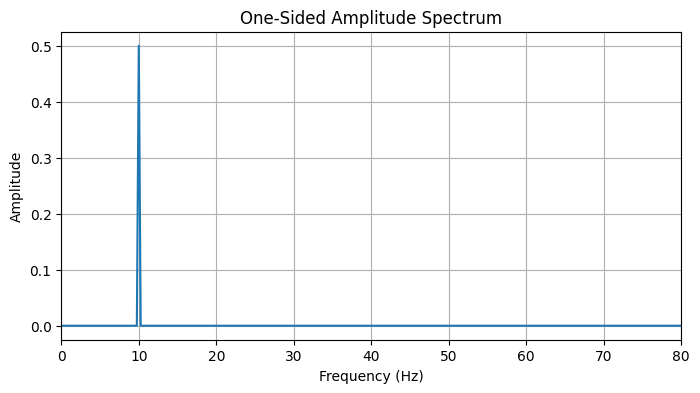

In [11]:
# Plot
plt.figure(figsize=(8, 4))
plt.plot(f, A)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('One-Sided Amplitude Spectrum')
plt.grid(True)
plt.xlim(0, 80)   # adjust as needed
plt.show()

The deterministic FFT does not change when rerun because the input signal is exactly the same each time. The sinusoid $x(t)=0.5cos⁡(2π10t)x(t)=0.5\cos(2\pi 10t)x(t)=0.5cos(2π10t)$ is generated from fixed parameters (amplitude, frequency, sampling rate, and duration) with no random component or noise. Since the FFT is a deterministic mathematical operation, applying it to the same signal always produces the same frequency spectrum. Therefore, the location and amplitude of the 10 Hz peak remain identical every time the calculation is repeated.

## 3.3: Noisy Channel

The theoretical power of the signal x[n] is $P_x = 0.125\ \text{V}^2.$ as derived in Section 3.1

With a target SNR of 0 dB, we can calculate the required noise power with...

$$P_n = \frac{P_x}{10^{\mathrm{SNR}_{dB}/10}}=\frac{0.125\text{V}^2}{10^{0/10}}= 0.125\text{V}^2$$

For a zero-mean AWGN, the noise power is equal to the noise variance, so $\sigma_n^2 = P_n=0.125\ \text{V}^2$. Thus, for a target SNR of 0 dB, the required noise variance of the noise signal should be $0.125\ \text{V}^2$.

The measured noise variance was 0.123528 V², which is within about 1.18% of the required noise variance. The measured SNR was 0.0509 dB, very close to the desired 0 dB. Small differences occur because the generated AWGN is finite set of random noise samples, so its sample statistics do not exactly match the theoretical values.

In [46]:
# Signal power of the clean sinusoid
signal_power_v2 = np.mean(x**2)

# 0 dB target SNR
noise_power_v2 = signal_power_v2

# Standard deviation corresponding to the required variance
noise_standard_deviation_v = np.sqrt(noise_power_v2)

rng = np.random.default_rng(7377)

# Generate AWGN realization
noise_samples = noise_standard_deviation_v * rng.standard_normal(N)

# Received signal
noisy_signal = x + noise_samples

# Measured noise variance
measured_noise_variance_v2 = np.var(noise_samples)

# Measured SNR
measured_snr_db = 10 * np.log10(
    np.mean(x**2) / np.mean(noise_samples**2)
)

print(f"Required noise variance: {noise_power_v2:.6f} V^2")
print(f"Measured noise variance: {measured_noise_variance_v2:.6f} V^2")
print(f"Measured SNR: {measured_snr_db:.4f} dB")

Required noise variance: 0.125000 V^2
Measured noise variance: 0.123528 V^2
Measured SNR: 0.0509 dB


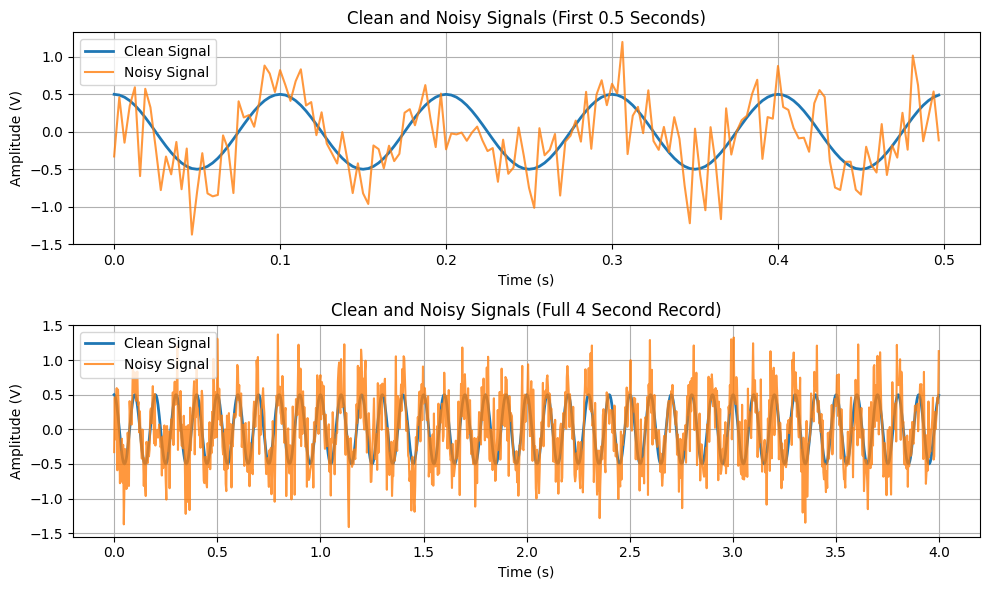

In [47]:
plt.figure(figsize=(10, 6))

# First 0.5 s
plt.subplot(2, 1, 1)
plt.plot(t[:160], x[:160], label="Clean Signal", linewidth=2)
plt.plot(t[:160], noisy_signal[:160], label="Noisy Signal", alpha=0.8)
plt.title("Clean and Noisy Signals (First 0.5 Seconds)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.grid(True)
plt.legend()

# Full 4 s record
plt.subplot(2, 1, 2)
plt.plot(t, x, label="Clean Signal", linewidth=2)
plt.plot(t, noisy_signal, label="Noisy Signal", alpha=0.8)
plt.title("Clean and Noisy Signals (Full 4 Second Record)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

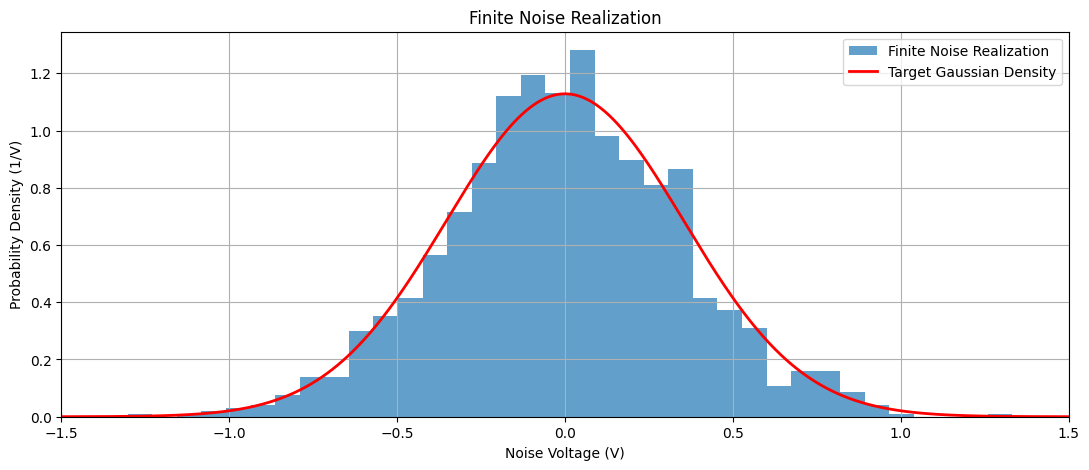

In [61]:
# Voltage axis for theoretical PDF
v = np.linspace(-1.5, 1.5, 1000)

# Target Gaussian PDF
gaussian_pdf = (
    1 / np.sqrt(2 * np.pi * noise_power_v2)
) * np.exp(
    -(v**2) / (2 * noise_power_v2)
)

plt.figure(figsize=(13, 5))

# Histogram of finite noise realization
plt.hist(
    noise_samples,
    bins=36,
    density=True,
    alpha=0.7,
    label="Finite Noise Realization"
)

# Theoretical Gaussian PDF
plt.plot(
    v,
    gaussian_pdf,
    'r',
    linewidth=2,
    label="Target Gaussian Density"
)

plt.xlim(-1.5, 1.5)

plt.xlabel("Noise Voltage (V)")
plt.ylabel("Probability Density (1/V)")
plt.title("Finite Noise Realization")
plt.grid(True)
plt.legend()

plt.show()

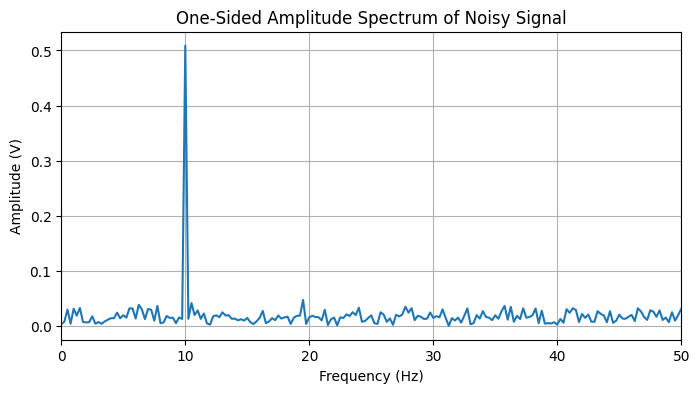

In [63]:
R = np.fft.rfft(noisy_signal)
freqs = np.fft.rfftfreq(N, d=1/fs)

# One-sided amplitude spectrum
R_amp = np.abs(R) / N
R_amp[1:-1] *= 2

plt.figure(figsize=(8,4))
plt.plot(freqs, R_amp)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (V)")
plt.title("One-Sided Amplitude Spectrum of Noisy Signal")
plt.grid(True)
plt.xlim(0, 50)
plt.show()

The clean signal has a mean near zero and a variance of approximately 0.125 V². After AWGN is added, the mean remains near zero because the noise is zero-mean, while the variance increases to approximately 0.25 V² due to the added noise power. The values are very close to the theoretical results but not exact because the AWGN is generated from a finite set of random samples, causing small variations in the measured statistics.

$Var(r)=Var(x)+Var(n)$ = 0.125 V² + 0.125 V² = 0.250 V²

In [38]:
# Clean signal statistics
mean_clean = np.mean(x)
var_clean = np.var(x)

# Noisy signal statistics
mean_noisy = np.mean(noisy_signal)
var_noisy = np.var(noisy_signal)

print("Clean Signal")
print(f"Mean     = {mean_clean:.6f}")
print(f"Variance = {var_clean:.6f} V^2")

print("\nNoisy Signal")
print(f"Mean     = {mean_noisy:.6f}")
print(f"Variance = {var_noisy:.6f} V^2")

Clean Signal
Mean     = -0.000000
Variance = 0.125000 V^2

Noisy Signal
Mean     = -0.003817
Variance = 0.252740 V^2


In the frequency domain, both signals exhibit a peak at 10 Hz, which corresponds to the original sinusoid. The noisy spectrum additionally contains a broadband noise floor across all frequencies because AWGN contains energy distributed over a wide range of frequencies. As a result, noise contributes small frequency components throughout the spectrum rather than at a single frequency. The clean spectrum contains essentially only the 10 Hz component, while the noisy spectrum shows the same 10 Hz peak superimposed on the elevated noise floor. Small variations in the noise floor are expected because the AWGN is generated from a finite set of random samples.

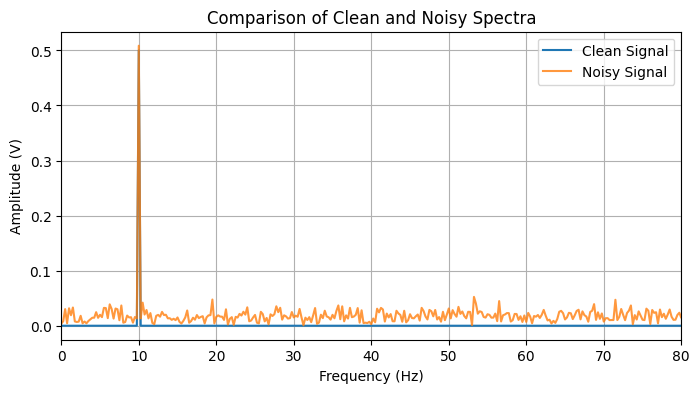

In [40]:
# Clean spectrum
X = np.fft.rfft(x)
X_amp = np.abs(X) / N
X_amp[1:-1] *= 2

# Noisy spectrum
R = np.fft.rfft(noisy_signal)
R_amp = np.abs(R) / N
R_amp[1:-1] *= 2

freqs = np.fft.rfftfreq(N, d=1/fs)

plt.figure(figsize=(8,4))

plt.plot(freqs, X_amp, label='Clean Signal')
plt.plot(freqs, R_amp, label='Noisy Signal', alpha=0.8)

plt.xlim(0, 80)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V)')
plt.title('Comparison of Clean and Noisy Spectra')
plt.grid(True)
plt.legend()

plt.show()

### 3.3.1: Different Default RNG Seed

Changing the random seed generates a different set of random noise samples. As a result, the noisy waveform changes, and the measured noise variance, measured SNR, mean, and variance of the noisy signal will be slightly different each time. However, these values should remain close to their theoretical values because the noise is generated with the same target variance. For example, the measured noise variance should stay close to 0.125 V² and the measured SNR should remain close to 0 dB, although they may be slightly above or below these values.

In [72]:
# Signal power of the clean sinusoid
signal_power_v2 = np.mean(x**2)

# 0 dB target SNR
noise_power_v2 = signal_power_v2

# Standard deviation corresponding to the required variance
noise_standard_deviation_v = np.sqrt(noise_power_v2)

rng = np.random.default_rng(120)

# Generate AWGN realization
noise_samples = noise_standard_deviation_v * rng.standard_normal(N)

# Received signal
noisy_signal = x + noise_samples

# Measured noise variance
measured_noise_variance_v2 = np.var(noise_samples)

# Measured SNR
measured_snr_db = 10 * np.log10(
    np.mean(x**2) / np.mean(noise_samples**2)
)

print(f"Required noise variance: {noise_power_v2:.6f} V^2")
print(f"Measured noise variance: {measured_noise_variance_v2:.6f} V^2")
print(f"Measured SNR: {measured_snr_db:.4f} dB")

rng = np.random.default_rng(7377)

Required noise variance: 0.125000 V^2
Measured noise variance: 0.123299 V^2
Measured SNR: 0.0583 dB


The measured mean and variance of the noisy signal also change slightly because of the different set of random noise samples. The noisy signal mean remains close to zero because the added AWGN is zero-mean, while the variance remains close to the expected value of approximately 0.25 V².

In [73]:
# Clean signal statistics
mean_clean = np.mean(x)
var_clean = np.var(x)

# Noisy signal statistics
mean_noisy = np.mean(noisy_signal)
var_noisy = np.var(noisy_signal)

print("Clean Signal")
print(f"Mean     = {mean_clean:.6f}")
print(f"Variance = {var_clean:.6f} V^2")

print("\nNoisy Signal")
print(f"Mean     = {mean_noisy:.6f}")
print(f"Variance = {var_noisy:.6f} V^2")

Clean Signal
Mean     = -0.000000
Variance = 0.125000 V^2

Noisy Signal
Mean     = -0.005765
Variance = 0.252696 V^2


The frequency spectrum also changes slightly because the noise samples are different. The 10 Hz peak remains at the same frequency and nearly the same amplitude since the sinusoidal signal is unchanged, but the shape of the noise floor varies from one realization to another. The noisy spectrum therefore looks slightly different each time even though its overall characteristics remain the same.

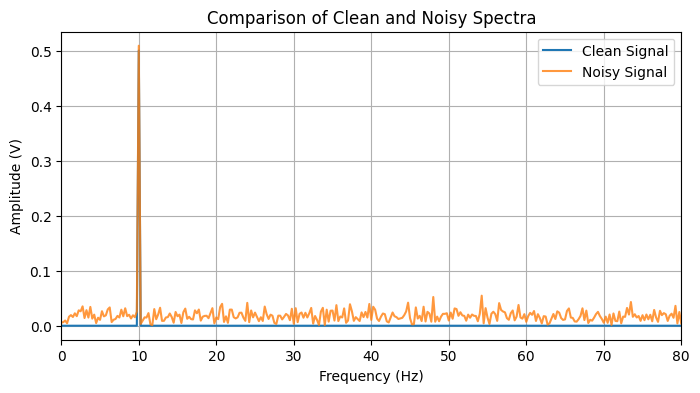

In [70]:
# Clean spectrum
X = np.fft.rfft(x)
X_amp = np.abs(X) / N
X_amp[1:-1] *= 2

# Noisy spectrum
R = np.fft.rfft(noisy_signal)
R_amp = np.abs(R) / N
R_amp[1:-1] *= 2

freqs = np.fft.rfftfreq(N, d=1/fs)

plt.figure(figsize=(8,4))

plt.plot(freqs, X_amp, label='Clean Signal')
plt.plot(freqs, R_amp, label='Noisy Signal', alpha=0.8)

plt.xlim(0, 80)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V)')
plt.title('Comparison of Clean and Noisy Spectra')
plt.grid(True)
plt.legend()

plt.show()

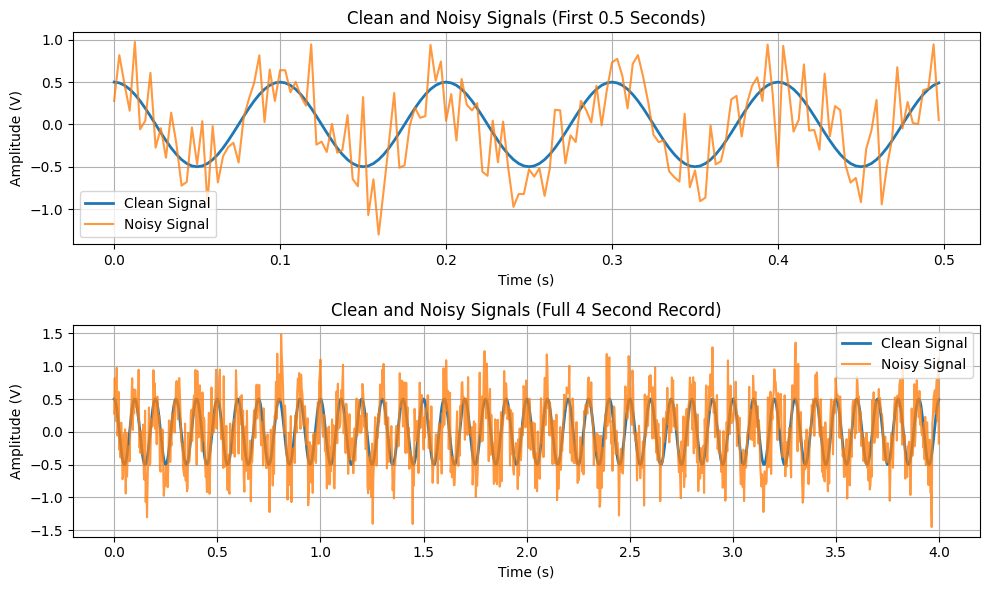

In [68]:
plt.figure(figsize=(10, 6))

# First 0.5 s
plt.subplot(2, 1, 1)
plt.plot(t[:160], x[:160], label="Clean Signal", linewidth=2)
plt.plot(t[:160], noisy_signal[:160], label="Noisy Signal", alpha=0.8)
plt.title("Clean and Noisy Signals (First 0.5 Seconds)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.grid(True)
plt.legend()

# Full 4 s record
plt.subplot(2, 1, 2)
plt.plot(t, x, label="Clean Signal", linewidth=2)
plt.plot(t, noisy_signal, label="Noisy Signal", alpha=0.8)
plt.title("Clean and Noisy Signals (Full 4 Second Record)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

This behavior can also be seen in the finite noise realization histogram. Changing the seed generates a different finite set of random samples, so the histogram changes shape slightly. Even though each realization follows the same Gaussian distribution, a finite number of samples will not perfectly match the theoretical Gaussian density. As more samples are used, the histogram would more closely match the target Gaussian curve.

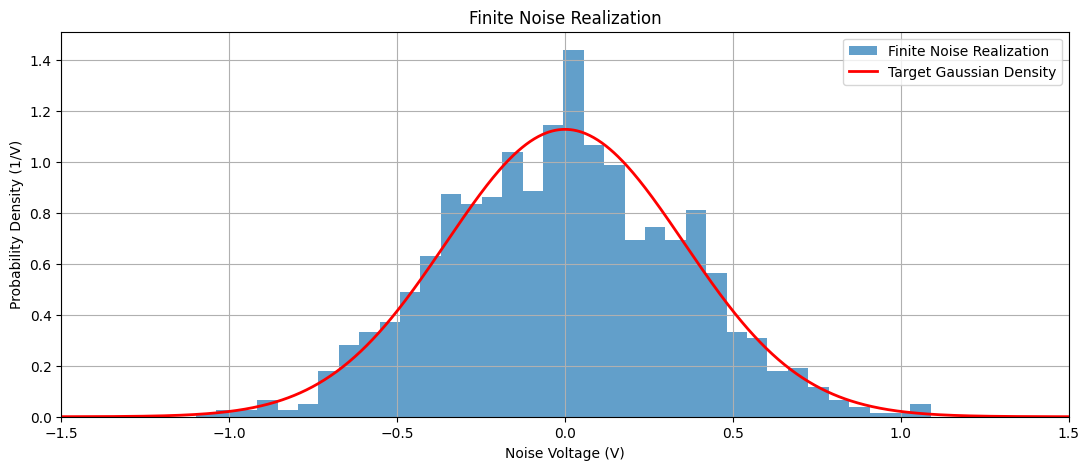

In [71]:
# Voltage axis for theoretical PDF
v = np.linspace(-1.5, 1.5, 1000)

# Target Gaussian PDF
gaussian_pdf = (
    1 / np.sqrt(2 * np.pi * noise_power_v2)
) * np.exp(
    -(v**2) / (2 * noise_power_v2)
)

plt.figure(figsize=(13, 5))

# Histogram of finite noise realization
plt.hist(
    noise_samples,
    bins=36,
    density=True,
    alpha=0.7,
    label="Finite Noise Realization"
)

# Theoretical Gaussian PDF
plt.plot(
    v,
    gaussian_pdf,
    'r',
    linewidth=2,
    label="Target Gaussian Density"
)

plt.xlim(-1.5, 1.5)

plt.xlabel("Noise Voltage (V)")
plt.ylabel("Probability Density (1/V)")
plt.title("Finite Noise Realization")
plt.grid(True)
plt.legend()

plt.show()

## 3.4: Welch PSD estimate

The Welch-bin spacing $\Delta f_{Welch}=\frac{f_s}{N_{FFT}}=\frac{320}{512}=0.625$ Hz with the number of Welch segment samples $N_{FFT}$ and sampling frequency $f_s$.

The amplitude change in dB between two amplitudes A1 and A2 is $20\log_{10}\left(\frac{A_2}{A_1}\right)$

Reducing the signal amplitude from 0.5 V to 0.1 V makes the amplitude change $20\log_{10}\left(\frac{0.1}{0.5}\right)=-13.98$ dB.

The power change in dB between two powers P2 and P1 is $10\log_{10}\left(\frac{P_2}{P_1}\right)$

Reducing the signal amplitude from 0.5 V to 0.1 V makes the power change $20\log_{10}\left(\frac{0.1^2}{0.5^2}\right)=-13.98$ dB because the power is proportional to the square of the amplitude.

In [77]:
from scipy import signal

welch_segment_samples = 512
welch_overlap_samples = 256

# Welch frequency-bin spacing
welch_bin_spacing_hz = fs / welch_segment_samples

welch_settings = {
    "fs": fs,
    "window": "hann",
    "nperseg": welch_segment_samples,
    "noverlap": welch_overlap_samples,
    "nfft": welch_segment_samples,
    "scaling": "density",
}

# Clean signal, A = 0.5 V
welch_frequency_hz, clean_psd = signal.welch(
    x,
    **welch_settings
)

# Noisy signal, A = 0.5 V
_, noisy_psd = signal.welch(
    noisy_signal,
    **welch_settings
)

# Reduced-amplitude signal, A = 0.1 V
x_reduced = 0.1 * np.cos(2 * np.pi * f0 * t)
reduced_noisy_signal = x_reduced + noise_samples

_, reduced_psd = signal.welch(
    reduced_noisy_signal,
    **welch_settings
)

# Amplitude and power changes
amplitude_change_db = 20 * np.log10(0.1 / 0.5)
power_change_db = 10 * np.log10((0.1**2) / (0.5**2))

print(f"Welch-bin spacing: {welch_bin_spacing_hz:.3f} Hz")
print(f"Amplitude change: {amplitude_change_db:.3f} dB")
print(f"Power change: {power_change_db:.3f} dB")

Welch-bin spacing: 0.625 Hz
Amplitude change: -13.979 dB
Power change: -13.979 dB


The Welch PSD estimate shows a strong spectral line near 10 Hz, which corresponds to the sinusoidal signal. This peak appears because most of the signal's power is concentrated at a single frequency. In the clean PSD, nearly all of the power is contained in this spectral line, with very little power at other frequencies.

The noisy PSD contains the same 10 Hz spectral line, but it also includes a broadband noise floor caused by the added AWGN. Unlike the sinusoid, which has power concentrated at one frequency, AWGN spreads its power across a wide range of frequencies. This causes the PSD to show nonzero power over much of the frequency spectrum.

The noise floor is not perfectly flat and shows small fluctuations from one frequency bin to another. This occurs because the Welch PSD is only an estimate based on a finite number of samples and overlapping segments. Since a finite realization of random noise is used, the estimated noise power varies slightly across frequency bins. These random fluctuations are known as finite-estimate variation and would decrease if a longer data record were used.

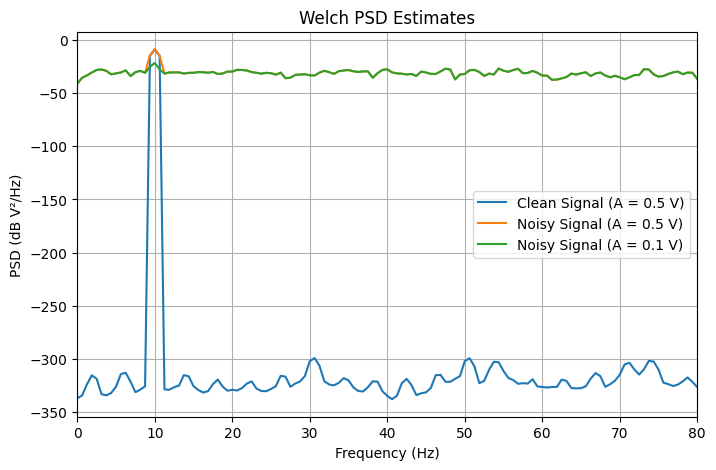

In [80]:
epsilon = 1e-35

plt.figure(figsize=(8,5))

plt.plot(
    welch_frequency_hz,
    10*np.log10(np.maximum(clean_psd, epsilon)),
    label='Clean Signal (A = 0.5 V)'
)

plt.plot(
    welch_frequency_hz,
    10*np.log10(np.maximum(noisy_psd, epsilon)),
    label='Noisy Signal (A = 0.5 V)'
)

plt.plot(
    welch_frequency_hz,
    10*np.log10(np.maximum(reduced_psd, epsilon)),
    label='Noisy Signal (A = 0.1 V)'
)

plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (dB V²/Hz)')
plt.title('Welch PSD Estimates')
plt.xlim(0, 80)
plt.grid(True)
plt.legend()

plt.show()

## 4. Task 2: Sampling Aliasing, and Filtering

## 4.1: Rectangular pulse

The first two positive theoretical zero crossings shuold occur at $f=\frac1{T_p},\frac2{T_p}$ because zero crossings occur when $fT_p=\pm 1, \pm 2, \pm 3$. Since $T_p=1$ second, the first two positive zeros should theoretically occur at f = 1 Hz and f = 2 Hz.

The graph below lists the sample rate $f_s=\frac{L}{T_p}$ and Nyquist Frequency $f_N=\frac{f_s}{2}$.

In [111]:
# Parameters supplied by the manual
pulse_width_s = 1.0
observation_s = 4.0
samples_per_pulse_values = [1, 2, 4, 8, 16, 32]

# Large FFT size to approximate the DTFT
fft_size = 16384

first_zero_hz = 1 / pulse_width_s
second_zero_hz = 2 / pulse_width_s

rectangular_records = []

for samples_per_pulse in samples_per_pulse_values:

    sample_rate_sps = samples_per_pulse / pulse_width_s

    nyquist_hz = sample_rate_sps / 2

    sample_interval_s = 1 / sample_rate_sps

    # Observe pulse in [-2, 2)
    time_s = np.arange(
        -observation_s / 2,
         observation_s / 2,
         sample_interval_s
    )

    # Rectangular pulse of width 1 second
    pulse = (np.abs(time_s) < pulse_width_s / 2).astype(float)

    # Centered zero-padded FFT
    sampled_spectrum = np.fft.fftshift(
        np.fft.fft(pulse, fft_size)
    )

    frequency_hz = np.fft.fftshift(
        np.fft.fftfreq(
            fft_size,
            d=sample_interval_s
        )
    )

    sampled_magnitude = np.abs(sampled_spectrum)
    sampled_magnitude /= np.max(sampled_magnitude)

    theoretical_magnitude = np.abs(
        np.sinc(frequency_hz * pulse_width_s)
    )

    rectangular_records.append({
        "samples_per_pulse": samples_per_pulse,
        "sample_rate_sps": sample_rate_sps,
        "nyquist_hz": nyquist_hz,
        "time_s": time_s,
        "pulse": pulse,
        "frequency_hz": frequency_hz,
        "sampled_magnitude": sampled_magnitude,
        "theoretical_magnitude": theoretical_magnitude,
    })

print(f"First two positive sinc zeros: {first_zero_hz:g}, {second_zero_hz:g} Hz")

for record in rectangular_records:
    print(
        f"L={record['samples_per_pulse']:2d}: "
        f"fs={record['sample_rate_sps']:5.1f} Hz, "
        f"Nyquist={record['nyquist_hz']:4.1f} Hz"
    )

First two positive sinc zeros: 1, 2 Hz
L= 1: fs=  1.0 Hz, Nyquist= 0.5 Hz
L= 2: fs=  2.0 Hz, Nyquist= 1.0 Hz
L= 4: fs=  4.0 Hz, Nyquist= 2.0 Hz
L= 8: fs=  8.0 Hz, Nyquist= 4.0 Hz
L=16: fs= 16.0 Hz, Nyquist= 8.0 Hz
L=32: fs= 32.0 Hz, Nyquist=16.0 Hz


For small values of L, the sampling rate and Nyquist frequency are too low to capture all of these zeros. For example, when L=1, the Nyquist frequency is only 0.5 Hz, so even the first theoretical zero at 1 Hz cannot be observed. As L increases, the Nyquist frequency increases and more of the sinc spectrum becomes visible, allowing additional zero crossings to be observed.

Increasing L improves the sampled representation because more samples are used to describe the pulse in time. This produces a more accurate approximation of the rectangular shape and a smoother FFT. However, the physical pulse width remains unchanged at $T_p=1$ second. Increasing L only changes the sampling density, not the actual duration of the pulse.

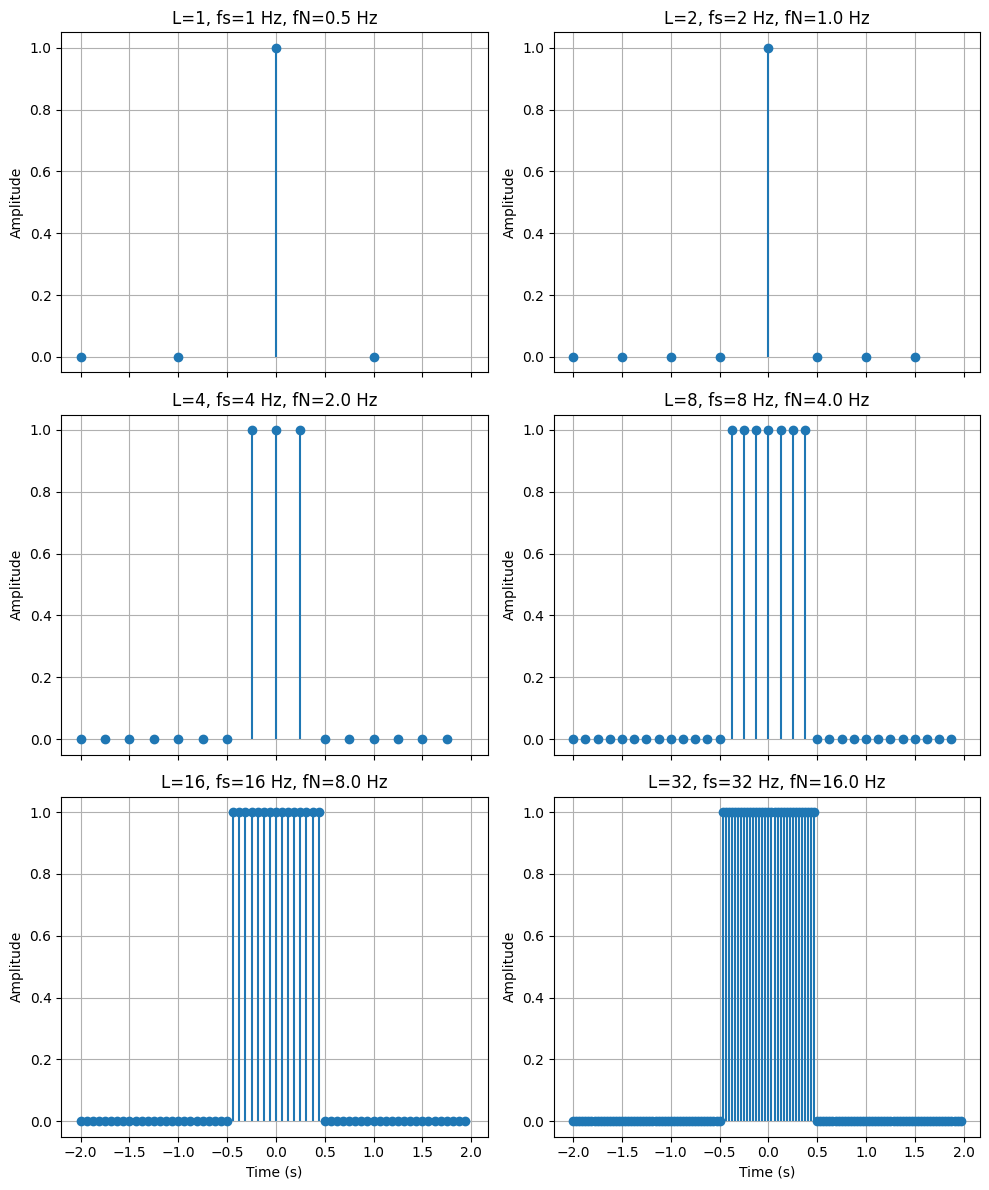

In [112]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3, 2,
    figsize=(10, 12),
    sharex=True
)

for ax, record in zip(
    axes.ravel(),
    rectangular_records
):

    ax.stem(
        record["time_s"],
        record["pulse"],
        basefmt=" "
    )

    ax.set_title(
        f"L={record['samples_per_pulse']}, "
        f"fs={record['sample_rate_sps']:.0f} Hz, "
        f"fN={record['nyquist_hz']:.1f} Hz"
    )

    ax.set_ylabel("Amplitude")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True)

axes[-1,0].set_xlabel("Time (s)")
axes[-1,1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

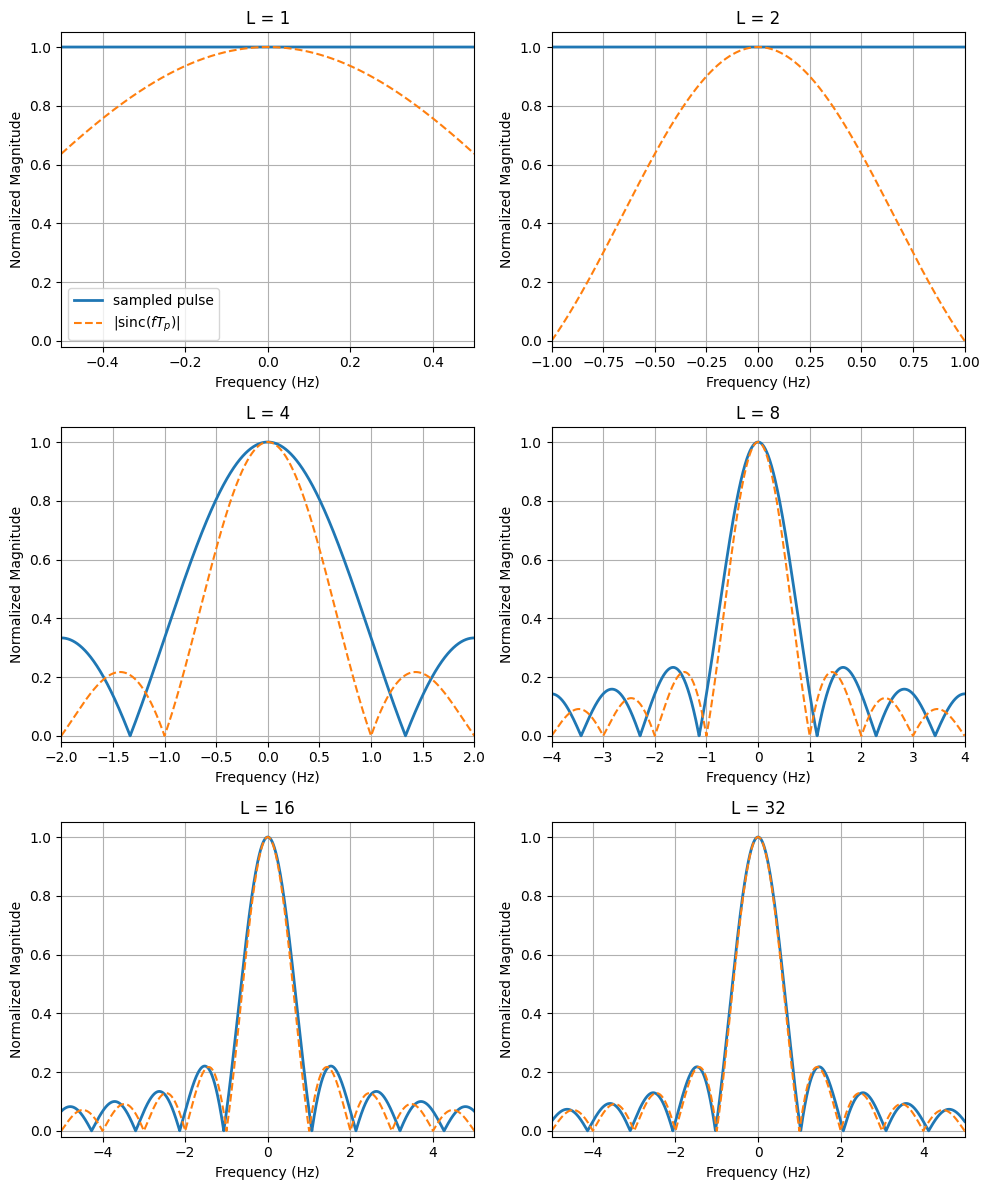

In [116]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for ax, record in zip(axes.ravel(), rectangular_records):

    fN = record["nyquist_hz"]

    ax.plot(
        record["frequency_hz"],
        record["sampled_magnitude"],
        label="sampled pulse",
        linewidth=2
    )

    ax.plot(
        record["frequency_hz"],
        record["theoretical_magnitude"],
        '--',
        label=r'$|\mathrm{sinc}(fT_p)|$',
        linewidth=1.5
    )

    if record["samples_per_pulse"] >= 16:
        ax.set_xlim(-5, 5)
    else:
        ax.set_xlim(-fN, fN)
    ax.set_ylim(-0.02, 1.05)

    ax.set_title(
        f"L = {record['samples_per_pulse']}"
    )

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Normalized Magnitude")
    ax.grid(True)

    if record["samples_per_pulse"] == 1:
        ax.legend()

plt.tight_layout()
plt.show()

## 4.2: Sinusoidal signals

The time duration of the signal $T=\frac{\text{Number of Cycles}}{f_0}=\frac{5}{10000\text{ Hz}}=0.0005$ seconds.

The sample count $N=f_sT=(0.0005)f_s$.

The Nyquist Frequency $f_N=\frac{f_s}{2}$.

The predicted principal alias frequency was calculated using $
f_{\text{alias}}
=
\left[
\left(
f_0 + \frac{f_s}{2}
\right)
\bmod f_s
\right]
-
\frac{f_s}{2}
$.

---

### Case 1: $f_s = 50f_0$

$$
f_s = 50(10\ \text{kHz})
= 500\ \text{kHz}
$$

$$
f_{\text{alias}}=\left[(10 + 250)\bmod 500\right]
-250=260-250=10\ \text{kHz}
$$

$$
f_N=\frac{f_s}{2}
=\frac{500}{2}
=250\ \text{kHz}
$$

$$
N=f_sT
=(500000)(0.0005)
=250
$$

---

### Case 2: $f_s = 8f_0$

$$
f_s = 8(10\ \text{kHz})
=80\ \text{kHz}
$$

$$
f_{\text{alias}}
=
\left[
(10+40)\bmod80
\right]
-40=
50-40
=10\ \text{kHz}
$$

$$
f_N=\frac{80}{2}
=40\ \text{kHz}
$$

$$
N=(80000)(0.0005)
=40
$$

---

### Case 3: $f_s = 4f_0$

$$
f_s = 4(10\ \text{kHz})
=40\ \text{kHz}
$$

$$
f_{\text{alias}}
=
\left[
(10+20)\bmod40
\right]
-20=
30-20=10\ \text{kHz}
$$

$$
f_N=\frac{40}{2}
=20\ \text{kHz}
$$

$$
N=(40000)(0.0005)
=20
$$

---

### Case 4: $f_s = 2f_0$

$$
f_s = 2(10\ \text{kHz})
=20\ \text{kHz}
$$

$$
f_{\text{alias}}
=
\left[
(10+10)\bmod20
\right]
-10=
0-10=-10\ \text{kHz}
$$

$$
f_N=\frac{20}{2}
=10\ \text{kHz}
$$

$$
N=(20000)(0.0005)
=10
$$

The signal lies exactly at the Nyquist frequency because the sampling frequency is exactly twice the signal frequency. With zero-phase sampling, the cosine is sampled at alternating peaks and valleys, alternating between $+1$ and $-1$. This result depends strongly on the sampling phase. If the sampling instants were shifted by a fraction of a period, a completely different sequence would be obtained. For example, sampling a quarter-period later would produce samples near zero. Because there are only two samples per cycle, the sampled signal does not uniquely determine the original continuous-time waveform. Small changes in sampling phase can therefore lead to very different sample sequences, even though the underlying sinusoid is the same. This sensitivity occurs because the signal is being sampled exactly at the Nyquist limit.

---

### Case 5: $f_s = f_0$

$$
f_s = 10\ \text{kHz}
$$

$$
f_{\text{alias}}
=
\left[
(10+5)\bmod10
\right]
-5=
5-5=0\ \text{kHz}
$$

$$
f_N=\frac{10}{2}
=5\ \text{kHz}
$$

$$
N=(10000)(0.0005)
=5
$$

The sampling frequency is the same as the signal frequency, so one sample is taken every cycle of the cosine. This means every sample is taken at the same point in the waveform, so all samples have the same value. Changing the phase changes what that constant value is, but the sequence remains constant. Because a constant sequence does not vary with time, its FFT contains only a DC component. Therefore, the original sinusoid aliases to 0 Hz regardless of the sampling phase.

In [118]:
# Parameters supplied by the manual
tone_hz = 10_000.0
cycles = 5
sample_rate_ratios = [50, 8, 4, 2, 1]

duration_s = cycles / tone_hz

reference_time_s = np.linspace(
    0,
    duration_s,
    3000,
    endpoint=False
)

reference_signal = np.cos(
    2 * np.pi * tone_hz * reference_time_s
)

sampling_records = []

for ratio in sample_rate_ratios:

    sample_rate_sps = ratio * tone_hz

    sample_count = int(
        np.round(duration_s * sample_rate_sps)
    )

    nyquist_hz = sample_rate_sps / 2

    time_s = np.arange(sample_count) / sample_rate_sps

    # Zero-phase cosine
    samples = np.cos(
        2 * np.pi * tone_hz * time_s
    )

    # Principal alias formula from the manual
    alias_hz = (
        ((tone_hz + sample_rate_sps / 2) % sample_rate_sps)
        - sample_rate_sps / 2
    )

    frequency_hz = np.fft.fftshift(
        np.fft.fftfreq(
            sample_count,
            d=1/sample_rate_sps
        )
    )

    spectrum = np.fft.fftshift(
        np.fft.fft(samples)
    )

    sampling_records.append({
        "ratio": ratio,
        "sample_rate_sps": sample_rate_sps,
        "sample_count": sample_count,
        "nyquist_hz": nyquist_hz,
        "time_s": time_s,
        "samples": samples,
        "alias_hz": alias_hz,
        "frequency_hz": frequency_hz,
        "spectrum": spectrum,
    })

for record in sampling_records:
    print(
        f"fs/f0={record['ratio']:2d}: "
        f"N={record['sample_count']:3d}, "
        f"Nyquist={record['nyquist_hz']/1e3:6.1f} kHz, "
        f"alias={record['alias_hz']/1e3:6.1f} kHz"
    )


fs/f0=50: N=250, Nyquist= 250.0 kHz, alias=  10.0 kHz
fs/f0= 8: N= 40, Nyquist=  40.0 kHz, alias=  10.0 kHz
fs/f0= 4: N= 20, Nyquist=  20.0 kHz, alias=  10.0 kHz
fs/f0= 2: N= 10, Nyquist=  10.0 kHz, alias= -10.0 kHz
fs/f0= 1: N=  5, Nyquist=   5.0 kHz, alias=   0.0 kHz


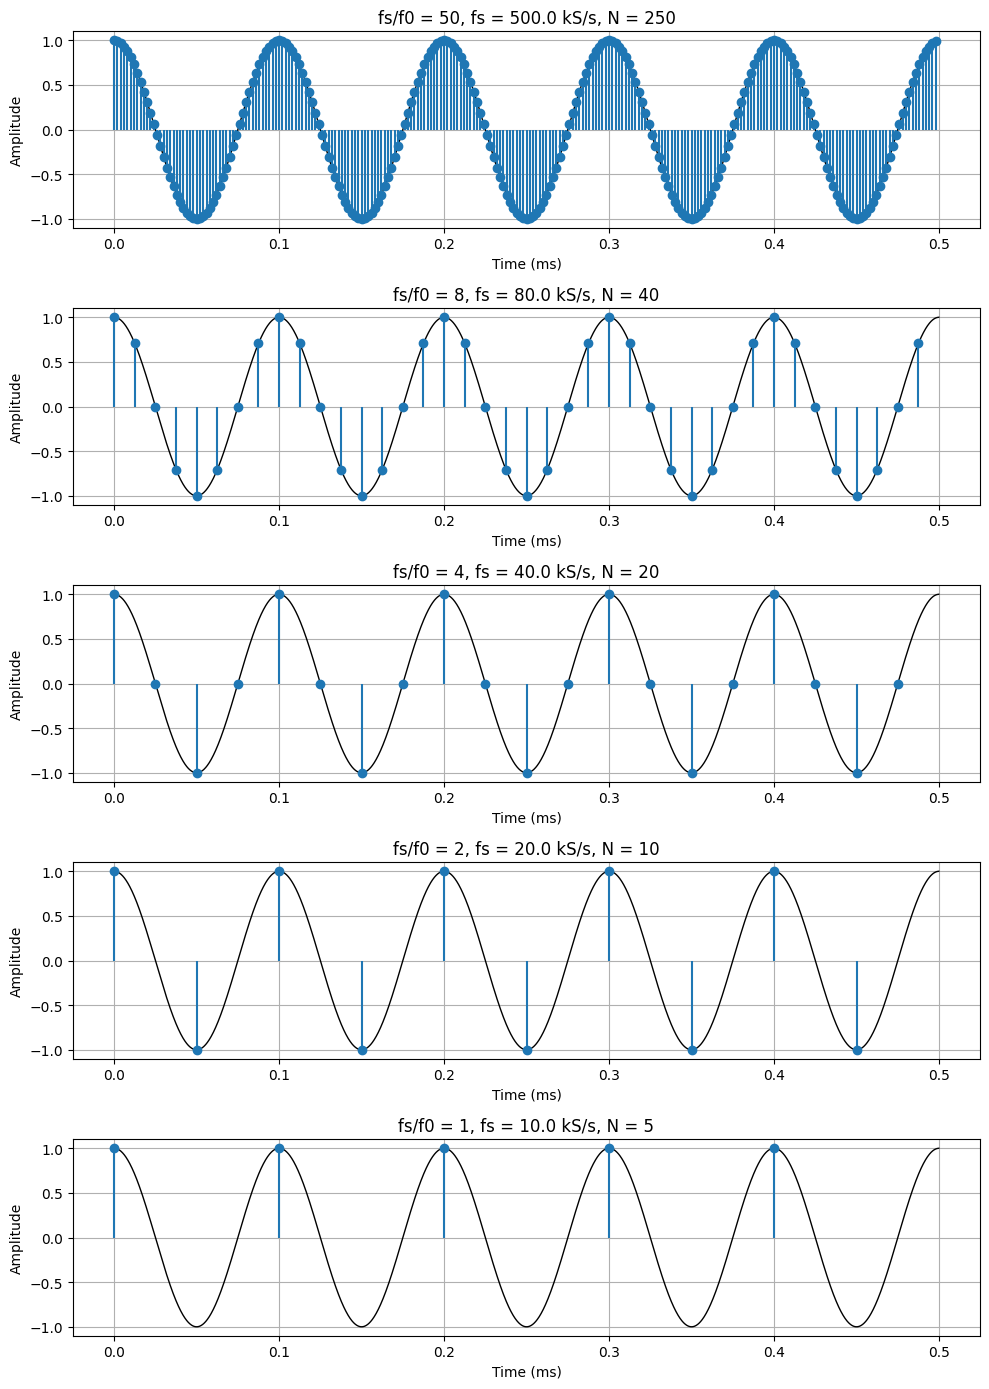

In [123]:
fig, axes = plt.subplots(
    len(sampling_records),
    1,
    figsize=(10, 14)
)

for ax, record in zip(axes, sampling_records):

    ax.plot(
        reference_time_s * 1e3,
        reference_signal,
        'k',
        linewidth=1,
        label='continuous reference'
    )

    ax.stem(
        record["time_s"] * 1e3,
        record["samples"],
        linefmt='C0-',
        markerfmt='C0o',
        basefmt=' '
    )

    ax.set_title(
        f"fs/f0 = {record['ratio']}, "
        f"fs = {record['sample_rate_sps']/1e3:.1f} kS/s, "
        f"N = {record['sample_count']}"
    )

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude")
    ax.grid(True)

plt.tight_layout()
plt.show()

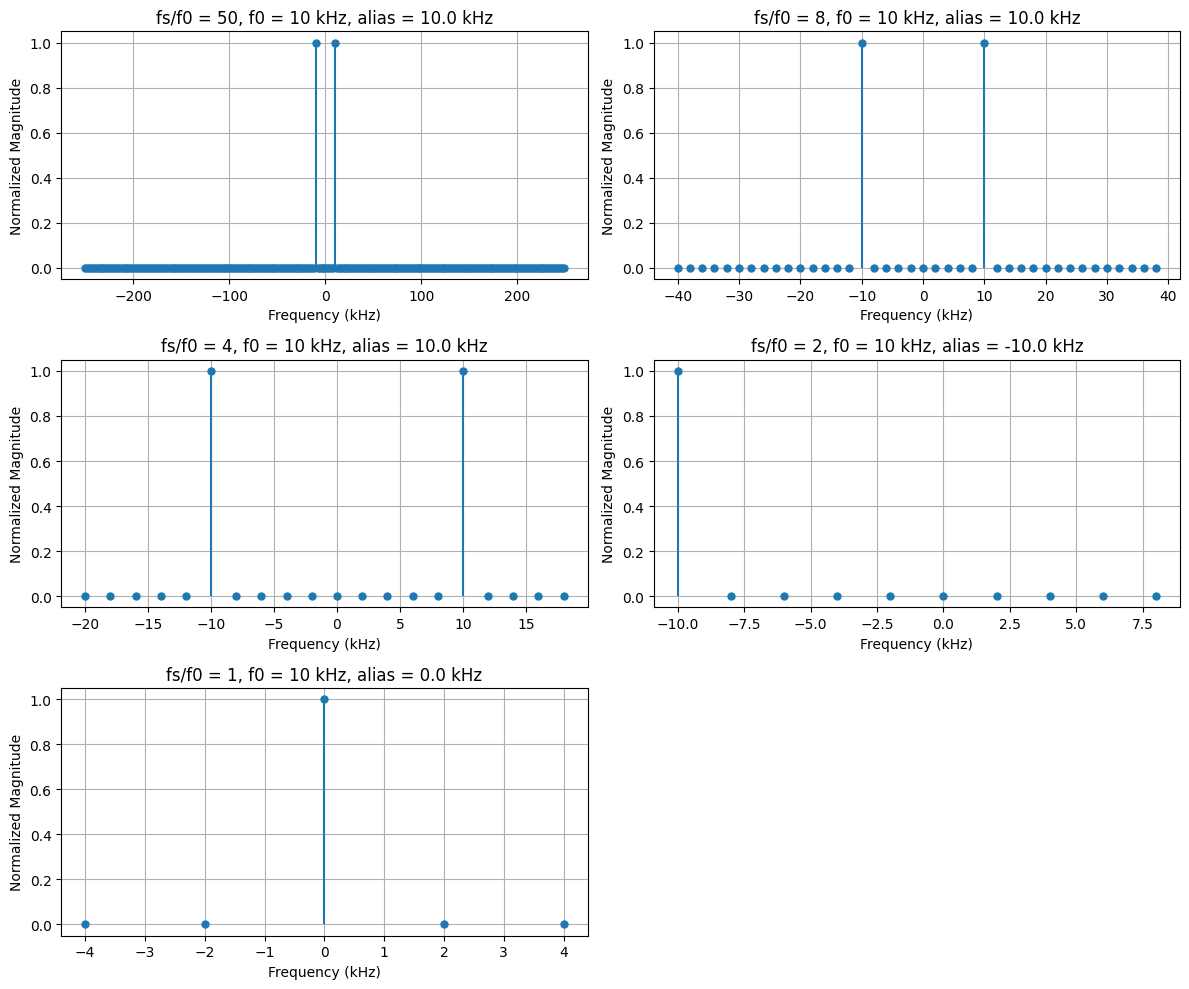

In [125]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 10)
)

axes = axes.ravel()

for ax, record in zip(axes[:5], sampling_records):

    magnitude = np.abs(record["spectrum"])

    if np.max(magnitude) > 0:
        magnitude /= np.max(magnitude)

    # Stem plot (spikes + dots)
    markerline, stemlines, baseline = ax.stem(
        record["frequency_hz"] / 1e3,
        magnitude,
        basefmt=" "
    )

    plt.setp(markerline, markersize=5)

    ax.set_title(
        f"fs/f0 = {record['ratio']}, "
        f"f0 = {tone_hz/1e3:.0f} kHz, "
        f"alias = {record['alias_hz']/1e3:.1f} kHz"
    )

    ax.set_xlabel("Frequency (kHz)")
    ax.set_ylabel("Normalized Magnitude")
    ax.grid(True)

# Remove unused sixth subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## 4.3: Aliasing and filters